In [1]:
import numpy as np

class preceptron:

  def __init__(self,eta = 0.1,n_iter = 50,random_state = 1):
    self.eta = eta
    self.n_iter = n_iter
    self.random_state = random_state

  def fit(self,X,y):
    regn = np.random.RandomState(self.random_state)
    self._w = regn.normal(loc=0.0,scale = 0.01,size = X.shape[1])
    self._b = np.float64(0.)
    self.error_ = []

    for _ in range(self.n_iter):
      error_per_epoch = 0

      for xi,target in zip(X,y):
        update = self.eta * (target - self.predict(xi))
        self._w += update*xi
        self._b += update
        error_per_epoch += int(update!=0.0)
      self.error_.append(error_per_epoch)

    return self

  def net_input(self,X):
    return np.dot(X,self._w)+ self._b

  def predict(self,X):
    return np.where(self.net_input(X)>=0,1,0)

In [2]:
import os
import pandas as pd

s = 'https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'


df = pd.read_csv(s,header=None,encoding='utf-8')
df.tail()

,0,1,2,3,4
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


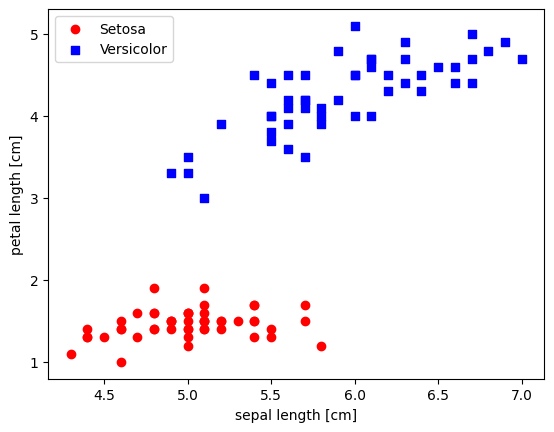

In [3]:
import matplotlib.pyplot as plt

y= df.  iloc[0:100,4].values
y= np.where(y=='Iris-setosa',1,0)
X= df.iloc[0:100,[0,2]].values

plt.scatter(X[:50,0] , X[:50,1],
            color = 'red', marker = 'o', label = 'Setosa')
plt.scatter(X[50:100,0] , X[50:100,1],
            color = 'blue', marker = 's', label = 'Versicolor')
plt.xlabel('sepal length [cm]')
plt.ylabel('petal length [cm]')

plt.legend(loc = 'upper left')
plt.show()


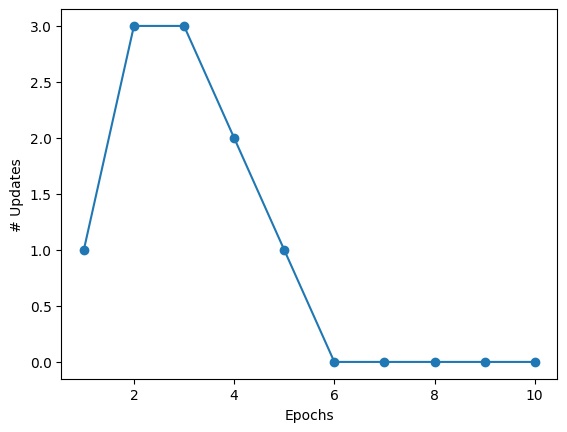

In [4]:
ppn  = preceptron(eta= 0.1,n_iter = 10)
ppn.fit(X,y)
plt.plot(range(1,len(ppn.error_)+1),
         ppn.error_, marker = 'o')
plt.xlabel('Epochs')
plt.ylabel('# Updates')
plt.show()

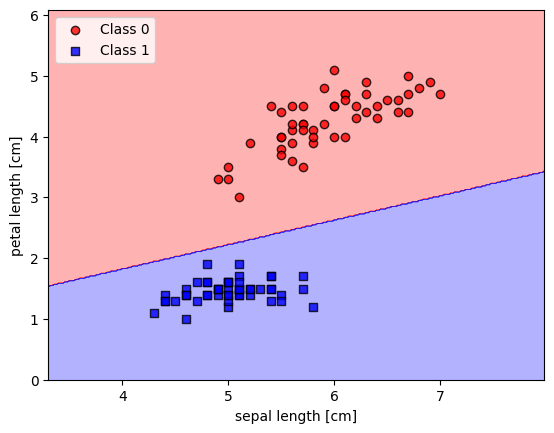

In [5]:
from matplotlib.colors import ListedColormap
import numpy as np # Add import for numpy
import matplotlib.pyplot as plt # Add import for matplotlib.pyplot

def plot_decision_regions(X, y, classifier, resolution=0.02):
 # setup marker generator and color map
 markers = ('o', 's', '^', 'v', '<')
 colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
 cmap = ListedColormap(colors[:len(np.unique(y))])

 # plot the decision surface
 x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
 x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
 xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
 np.arange(x2_min, x2_max, resolution))
 lab = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
 lab = lab.reshape(xx1.shape)
 plt.contourf(xx1, xx2, lab, alpha=0.3, cmap=cmap)
 plt.xlim(xx1.min(), xx1.max())
 plt.ylim(xx2.min(), xx2.max())

 # plot class examples
 for idx, cl in enumerate(np.unique(y)):
  plt.scatter(x=X[y == cl, 0],
  y=X[y == cl, 1],
  alpha=0.8,
  c=colors[idx],
  marker=markers[idx],
  label=f'Class {cl}',
  edgecolor='black')

plot_decision_regions(X, y, classifier=ppn)

plt.xlabel('sepal length [cm]')
plt.ylabel('petal length [cm]')

plt.legend(loc = 'upper left')
plt.show()

In [6]:
class AdalineGD:

  def __init__(self,eta = 0.01,n_iter = 50,random_state = 1):
    self.eta = eta
    self.n_iter = n_iter
    self.random_state = random_state

  def fit(self,X,y):
    regn = np.random.RandomState(self.random_state)
    self._w = regn.normal(loc=0.0,scale = 0.01,size = X.shape[1])
    self._b = np.float64(0.)
    self.losses_ = []

    for i in range(self.n_iter):
      net_input = self.net_input(X)
      output = self.activation(net_input)
      errors = (y-output)
      self._w += self.eta*2.0*X.T.dot(errors)/X.shape[0]
      self._b += self.eta*2.0*errors.mean()
      loss = (errors**2).mean()
      self.losses_.append(loss)
    return self

  def net_input(self,X):
    return np.dot(X,self._w)+ self._b

  def activation(self,X):
    return X

  def predict(self,X):
    return np.where(self.activation(self.net_input(X))>=0.5,1,0)

Text(0.5, 1.0, 'Adaline error rate 0.0001')

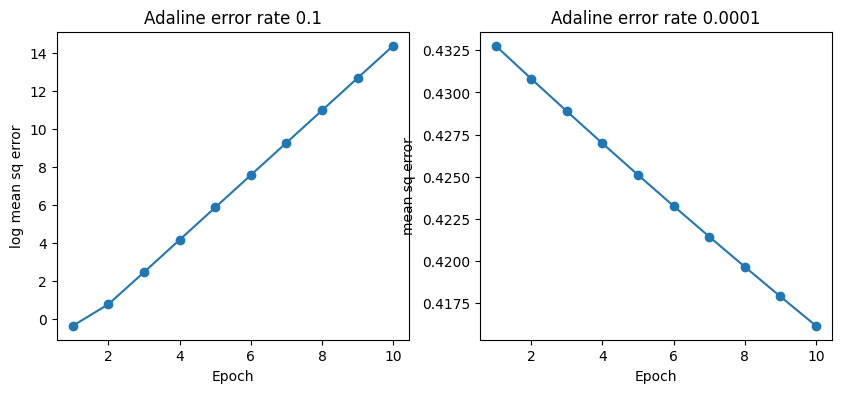

In [7]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (10,4))
ada1 = AdalineGD(n_iter = 10 , eta = 0.1).fit(X,y)
ax[0].plot(range(1,len(ada1.losses_)+1),np.log10(ada1.losses_),marker = 'o')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('log mean sq error')
ax[0].set_title('Adaline error rate 0.1')

ada2 = AdalineGD(n_iter = 10 , eta = 0.0001).fit(X,y)
ax[1].plot(range(1,len(ada2.losses_)+1),ada2.losses_,marker = 'o')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('mean sq error')
ax[1].set_title('Adaline error rate 0.0001')

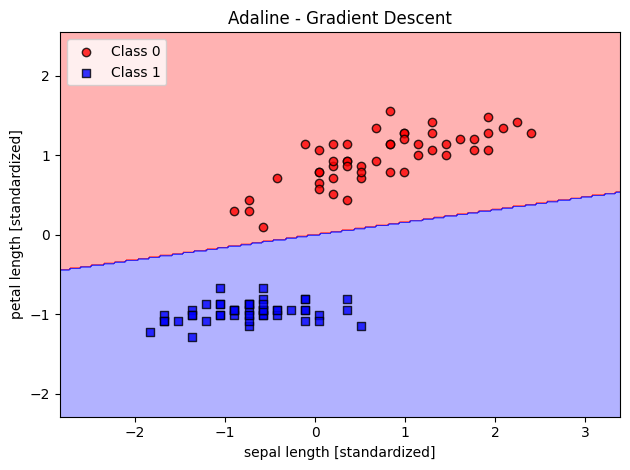

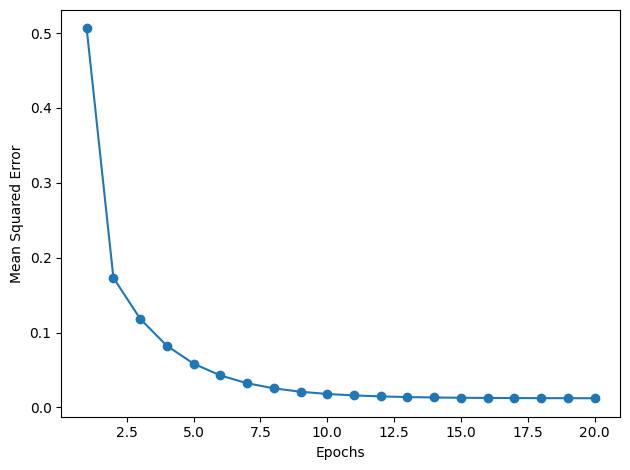

In [8]:
X_std = X.copy()
X_std[:,0] = (X[:,0] - X[:,0].mean())/X[:,0].std()
X_std[:,1] = (X[:,1] - X[:,1].mean())/X[:,1].std()

ada_gd = AdalineGD(n_iter=20,eta = 0.5)
ada_gd.fit(X_std,y)

plot_decision_regions(X_std,y,classifier = ada_gd)
plt.title('Adaline - Gradient Descent')
plt.xlabel('sepal length [standardized]')
plt.ylabel('petal length [standardized]')
plt.legend(loc = 'upper left')
plt.tight_layout()
plt.show()

plt.plot(range(1,len(ada_gd.losses_)+1),ada_gd.losses_,marker = 'o')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.tight_layout()
plt.show()

In [44]:
class AdalineSGD:
  def __init__(self,eta=0.01,n_iter = 10, shuffle = True, random_state = None):
    self.eta = eta
    self.n_iter = n_iter
    self.shuffle = shuffle
    self.W_initialized = False
    self.random_state = random_state



  def fit(self,X,y):
    self._initialized_weights(X.shape[1])
    self.losses_ = []

    for i in range(self.n_iter):
      if self.shuffle:
        X,y = self._shuffle(X,y)
      losses = []
      for xi, target in zip(X,y):
        losses.append(self._update_weights(xi,target))
      avg_loss = np.mean(losses)
      self.losses_.append(avg_loss)
    return self

  def _initialized_weights(self,m):
    self.regen = np.random.RandomState(self.random_state)
    self.w_ = self.regen.normal(loc=0.0, scale = 0.01,size = m )
    self.b_ = np.float64(.0)
    self.W_initialized = True

  def _update_weights(self,xi,target):
    output = self.activation(self.net_input(xi))
    error = (target-output)
    self.w_ += self.eta*2.0*xi*error
    self.b_ += self.eta*2.0*error
    loss = error**2
    return loss
  def _shuffle(self,X,y):
    r = self.regen.permutation(len(y))
    return X[r],y[r]



  def net_input(self,X):
    return np.dot(X,self.w_) + self.b_

  def activation(self,X):
    return X


  def partial_fit(self,X,y):
    if not self.W_initialized:
      self._initialized_weights(X.shape(1))
    if y.ravel().shape[0]>1:
      for xi,target in zip(X,y):
        self._update_weights(xi,target)
    else:
      self._update_weights(X,y)
    return self

  def predict(self,X):
    return np.where(self.activation(X=self.net_input(X))>= 0.5,1,0)





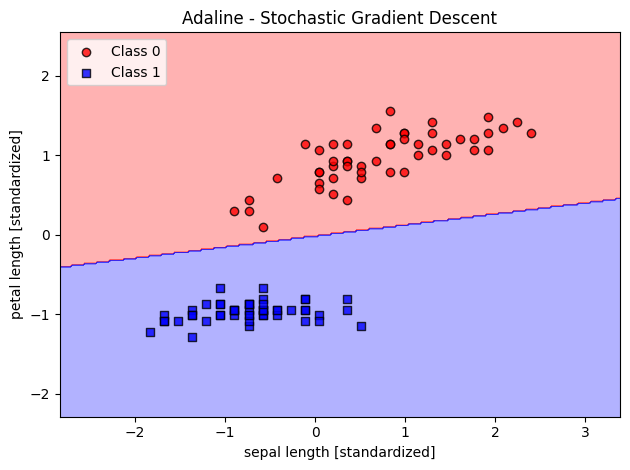

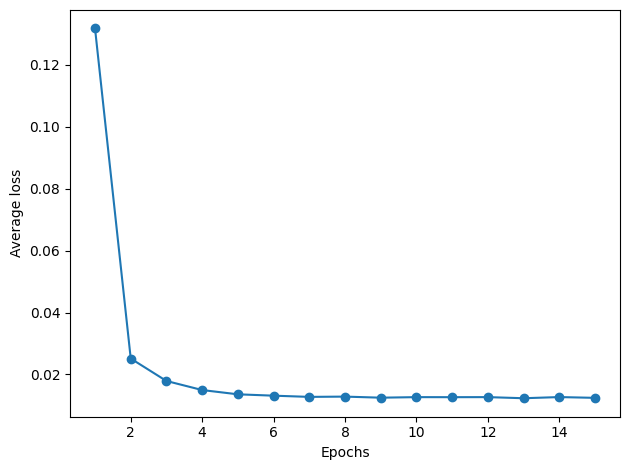

In [45]:
ada_sgd = AdalineSGD(n_iter = 15,eta=0.01,random_state = 1)
ada_sgd.fit(X_std,y)
plot_decision_regions(X_std,y,classifier = ada_sgd)
plt.title('Adaline - Stochastic Gradient Descent')
plt.xlabel('sepal length [standardized]')
plt.ylabel('petal length [standardized]')
plt.legend(loc = 'upper left')
plt.tight_layout()
plt.show()

plt.plot(range(1,len(ada_sgd.losses_)+1),ada_sgd.losses_,marker = 'o')
plt.xlabel('Epochs')
plt.ylabel('Average loss')
plt.tight_layout()
plt.show()



